# Signal and Image Processing (SIP SS26)

### Research Group Neuroinformatics, Faculty of Computer Science,
### University of Vienna


###  Signals and Systems

Lecturer: Prof. Moritz GROSSE-WENTRUP

Tutorial by: Sadiq A. ADEDAYO
$\quad\quad\quad\quad$ Jakob PRAGER 
$\quad\quad\quad\quad$ Kerim ATAK (kerim.atak@univie.ac.at)

In [1]:
# imports packages required (Numpy and Matplotlib)

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.signal as sig
import scipy.io.wavfile as wav
import sounddevice as sd

## Signals

A **signal** is an ordered sequence of numbers. In this course, we mainly consider **discrete-time signals**, written as

$$
x[n], \quad n \in \mathbb{Z}
$$

In practice, when working on a computer, we often represent a finite segment of such a signal, for example from $n = 0$ to $n = N-1$, as a **NumPy array**.

So conceptually, a discrete-time signal is defined for all integer indices $n$, while computationally we usually work with a finite-length portion of it.

Create a discrete-time signal x[n] of length 10 with values:
x[n] = 
\begin{cases}
1 & \text{if  } n = 2, 3, 4 \\
0 & \text{otherwise}
\end{cases}


In [2]:
x = np.zeros(10)
x[2:5] = 1
print(x)

[0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]


Plot the signal using a **stem plot** to emphasize its discrete nature.

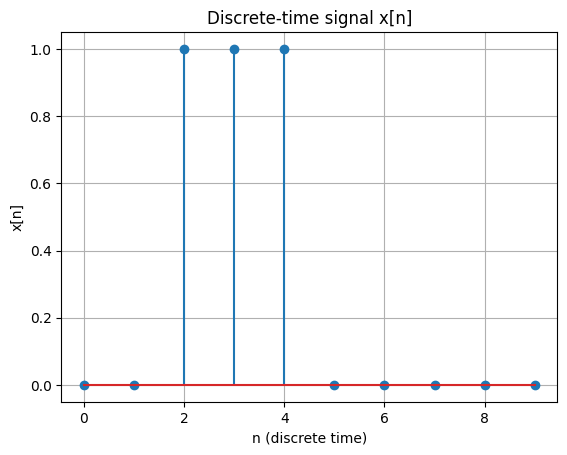

In [3]:
plt.stem(x)
plt.xlabel('n (discrete time)')
plt.ylabel('x[n]')
plt.title('Discrete-time signal x[n]')
plt.grid()
plt.show()

## Convolution


The **convolution** of two discrete-time signals $x[n]$ and $h[n]$ is defined as

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k].
$$

In signal processing, we typically interpret

- $x[n]$ as the **input signal**,
- $h[n]$ as the **impulse response** of a system,
- $y[n]$ as the **output signal**.

So convolution describes how a linear time-invariant (LTI) system transforms the input $x[n]$ through its impulse response $h[n]$.

> **Intuition.**  
> Convolution tells us how strongly the input signal $x[\cdot]$ matches a **shifted and flipped** version of the impulse response $h[\cdot]$.  
> For each value of $n$, we take $h[n-k]$, multiply it pointwise with $x[k]$, and sum over all $k$.  
> In this way, each output value $y[n]$ is a weighted sum of input values, where the weights are determined by the impulse response.  
>  
> You can think of it as follows: the system has a characteristic reaction $h[n]$ to a single impulse, and the input signal is built from many such impulses at different times and amplitudes. Convolution adds up all these shifted responses to produce the final output.

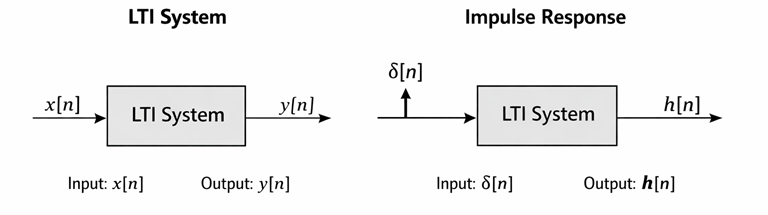
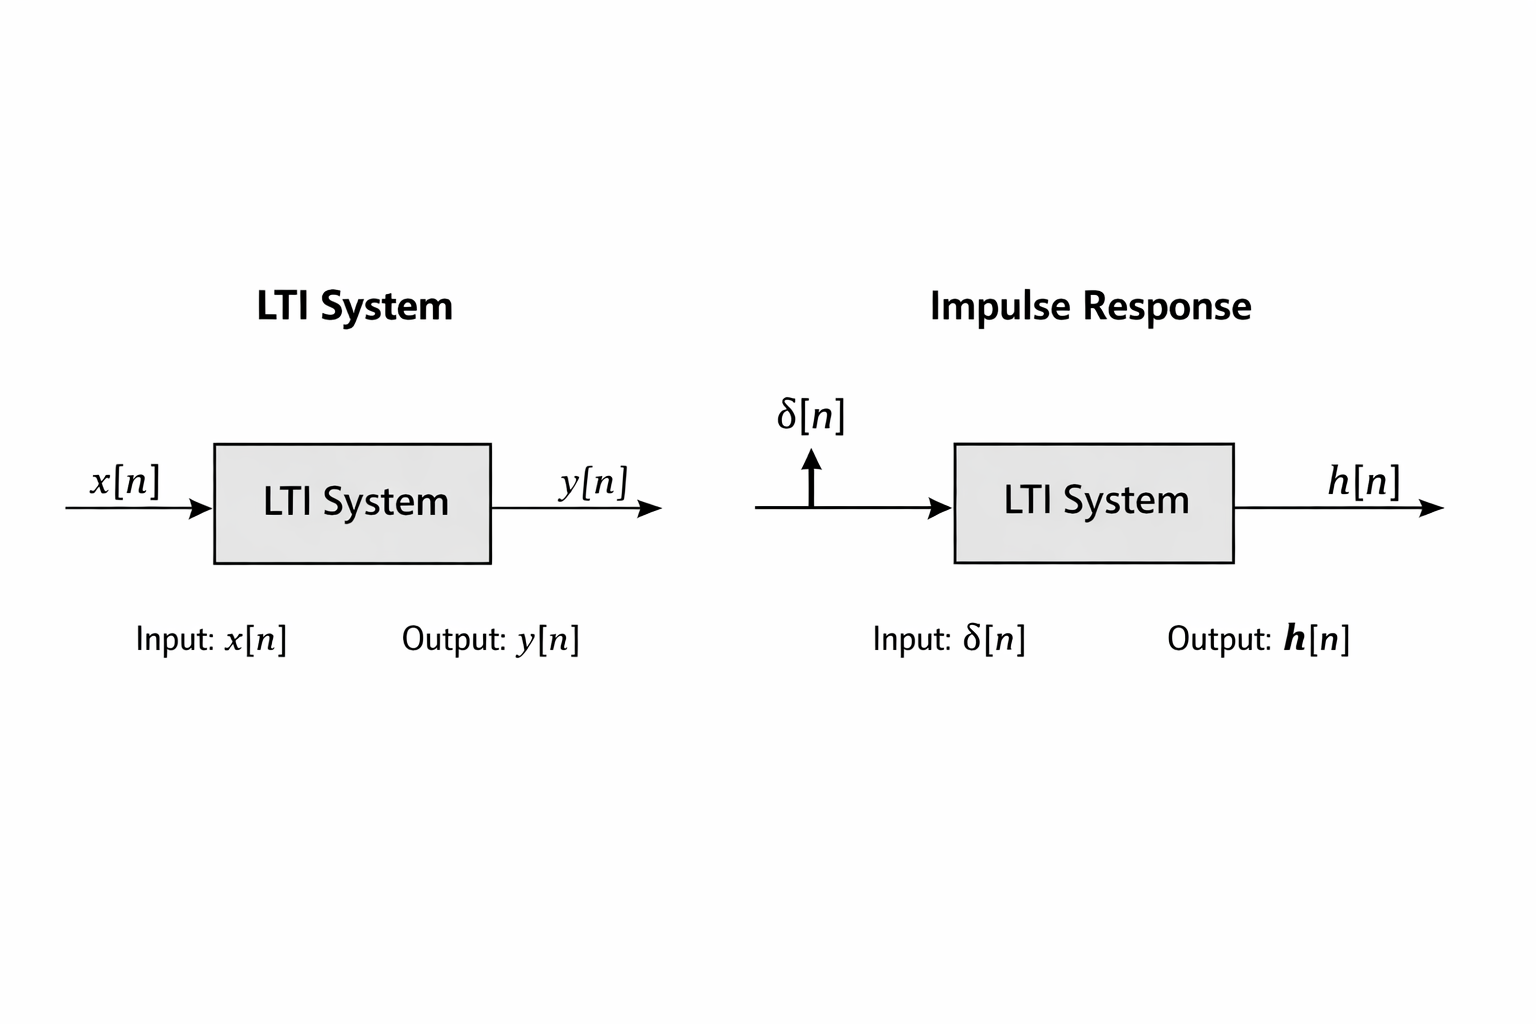

The following animations illustrate the two types of convolution: **discrete-time convolution** and **continuous-time convolution**.

Sources 
- [Digital signal](https://e2eml.school/convolution_one_d.html)
- [Continous signal](https://commons.wikimedia.org/wiki/File:Convolution_of_box_signal_with_itself2.gif)

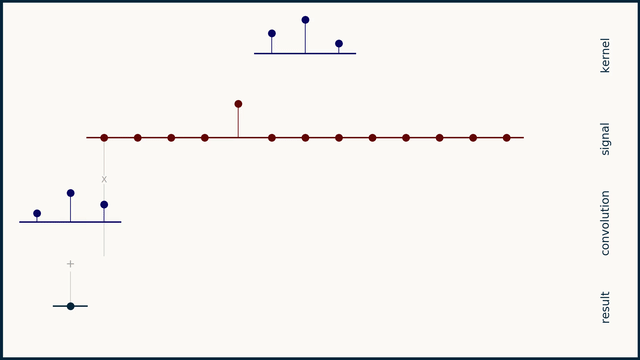

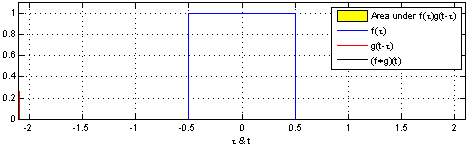

In the following code cell, write a function `lin_convolution(x, h)` that takes two inputs—the signal $x[n]$ and the impulse response $h[n]$—and computes the **linear convolution**, returning the output signal $y[n]$.

You are encouraged to use the hints provided to solve the task; however, please note that these are merely suggestions. Please note, this implementation is not optimized for run time, hence more time efficient implementations exist as that of [numpy.convolve()](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) and [scipy.signal.convolve()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html).

In [4]:
# Function to plot signals
# For adequate visualization of results, we will use the stem plot from matplotlib

def plot_signal(x, title, xlabel, ylabel, figsize=(6, 8), subplot=None):
    if subplot is not None:
        plt.subplot(subplot) 
    else:
        plt.figure(figsize=figsize)
    plt.stem(x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel, rotation=60)
    plt.xticks(np.arange(0, len(x), step=1))
    plt.grid()

In [5]:
def lin_convolution(x, h):
    K = len(x)
    
    # Initialize the output vector
    N = len(x) + len(h) - 1
    y = np.zeros(N)
    
    for n in range(N):
        for k in range(K):
            # Check if the index is out of bounds
            if n-k < 0 or n-k >= len(h):
                continue
            # Compute the convolution
            y[n] += x[k] * h[n-k]
    
    return y

In [6]:
# def lin_convolution(x, h):
#     # determine the size of convolution output
#     N = len(x) + len(h)-1
    
#     # initialize array of zeros for the output signal
#     y = np.zeros(N)
    
#     # determine number of zeros required to pad both `x[t]` and `h[t]`, i and j respectively
#     i = N - len(x) 
#     j = N - len(h)
    
#     # zero-pad x[t] and h[t] to the same size
#     x_padded = np.pad(x, (0, i), 'constant')
#     h_padded = np.pad(h, (0, j), 'constant')
    
#     # perform linear convolution
#     for n in range(N): 
#         for k in range(N):
#             if n-k >= 0:
#                 y[n] += x_padded[k]*h_padded[n-k]
            
#     return y

Next, we will test `lin_convolution(x, h)` on some example signals and compare the result with NumPy's implementation.

For consistency, we choose

- $x[n] = [1, 2, 0, 1]$
- $h[n] = [2, 2, 1, 1]$

We expect our function to return

$$
y[n] = [2, 6, 5, 5, 4, 1, 1],
$$

which is the same result obtained with `np.convolve(x, h, mode='full')`.

Once we have confirmed that our function works correctly, we can test it on other signals of different lengths.

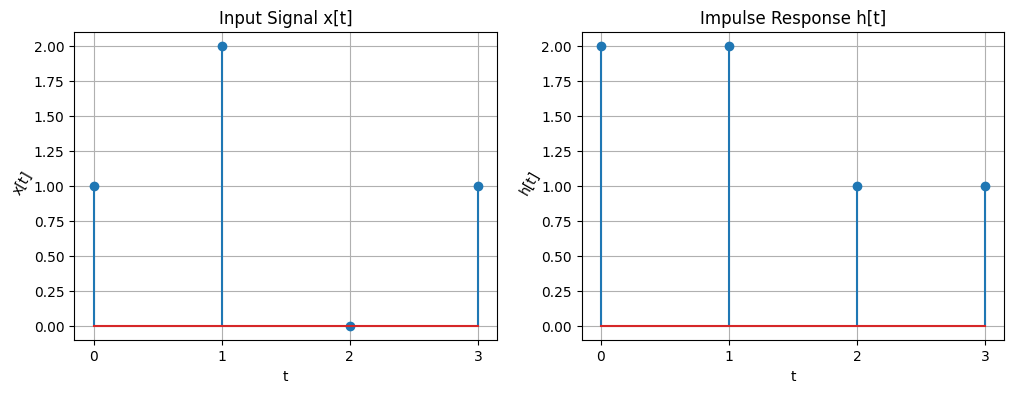

In [7]:
# Define the input signal x[t] and the impulse response h[t]

x = [1, 2, 0, 1]
h = [2, 2, 1, 1]



# plot the input signal x[t] and the impulse response h[t]

plt.figure(figsize=(12, 4))
plot_signal(x, 'Input Signal x[t]', 't', 'x[t]', subplot=121)
plot_signal(h, 'Impulse Response h[t]', 't', 'h[t]', subplot=122)
plt.show()

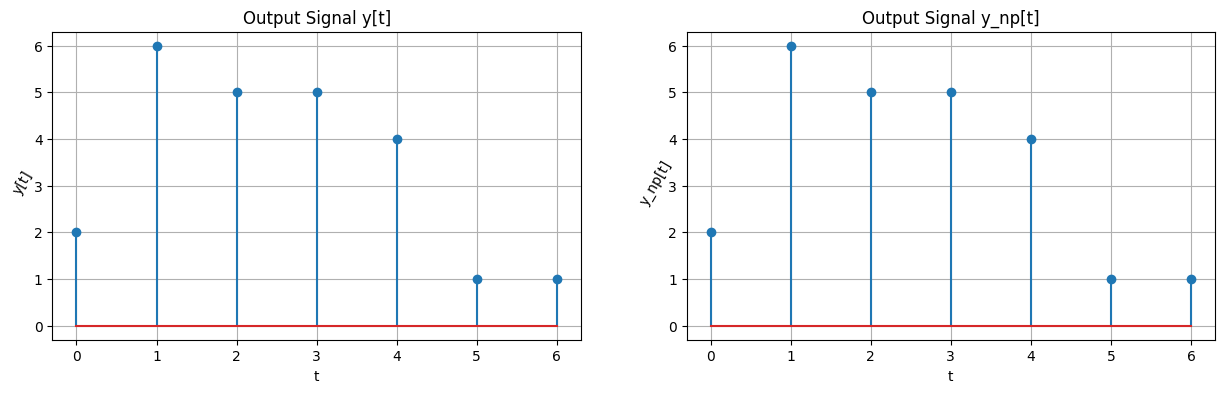

In [8]:
y = lin_convolution(x, h)  # call the written function here on x and h 
y_np = np.convolve(x, h, mode = 'full') # call the numpy convolve() function with mode "full" on x and h



# plot the output signal y[t] and the output signal y_np[t]

plt.figure(figsize=(15, 4))
plot_signal(y, 'Output Signal y[t]', 't', 'y[t]', subplot=121)
plot_signal(y_np, 'Output Signal y_np[t]', 't', 'y_np[t]', subplot=122)
plt.show()

### 3 modes of convolution

Besides `full`, there are two other commonly used convolution modes: `valid` and `same`. These modes do not fundamentally alter the convolution itself. Instead, they specify which part of the **full linear convolution** is returned and thus determine the length of the output.

#### Valid Mode

In `valid` mode, the convolution is computed only for those shifts at which the two signals fully overlap. Equivalently, we retain only the part of the **full linear convolution** for which the impulse response $h[n]$ lies entirely within the signal $x[n]$.

If $h[n]$ is shorter than $x[n]$, then the output signal $y[n]$ is shorter than $x[n]$.

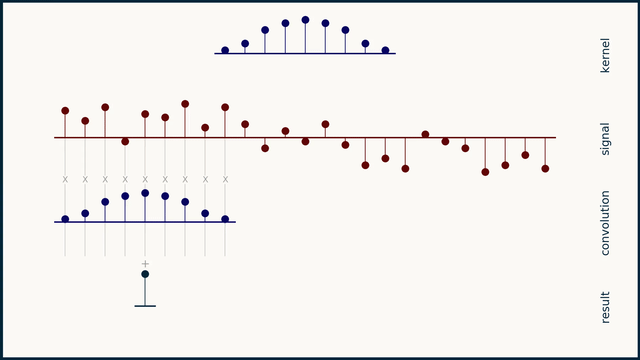

[Source](https://e2eml.school/convolution_one_d.html)

In the following, the numpy convolution mode "valid" is implemented.

In [9]:
def lin_convolution_valid(x, h):

    # perform linear convolution
    y = lin_convolution(x, h)


    # truncating result of "full" convolution

    p = np.max([len(x), len(h)]) - np.min([len(x), len(h)]) + 1     # p is the length of the sequence after truncation
    s = len(y)      # s is the length of the sequence after convolution
    
    if p%2 == 1:
        conv = y[s//2-p//2 : s//2+p//2+1]
    else:
        conv = y[s//2-p//2 : s//2+p//2]

    return conv.astype(int)

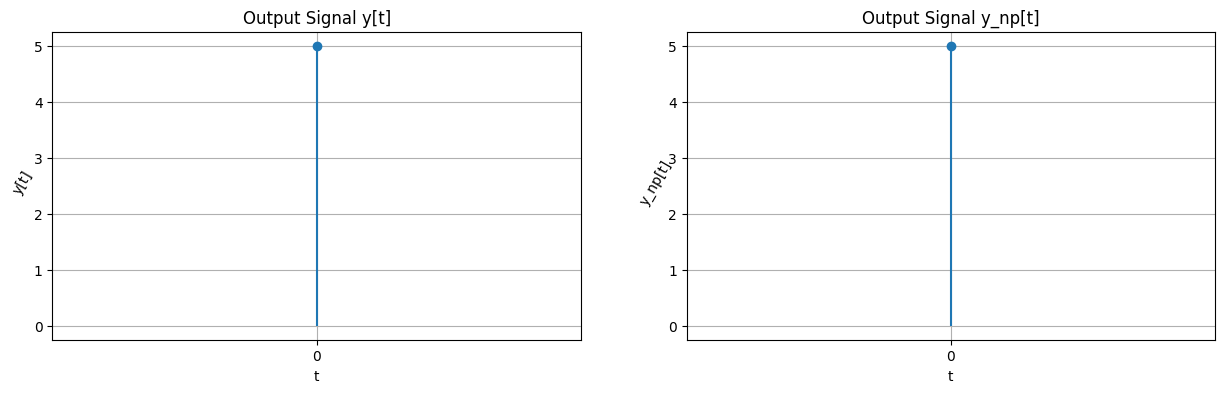

In [10]:
y = lin_convolution_valid(x, h)  # call the written function here on x and h
y_np = np.convolve(x, h, mode = 'valid') # call the numpy convolve() function with mode "valid" on x and h



# plot the output signal y[t] and the output signal y_np[t]

plt.figure(figsize=(15, 4))
plot_signal(y, 'Output Signal y[t]', 't', 'y[t]', subplot=121)
plot_signal(y_np, 'Output Signal y_np[t]', 't', 'y_np[t]', subplot=122)
plt.show()

#### Same Mode

In `same` mode, the convolution output is chosen such that the result $y[n]$ has the same length as the input signal $x[n]$. This is done by computing the **full linear convolution** and then keeping the central part of the result.

Thus, `same` mode does not change the convolution itself; it only selects the portion of the full result whose length matches that of $x[n]$.

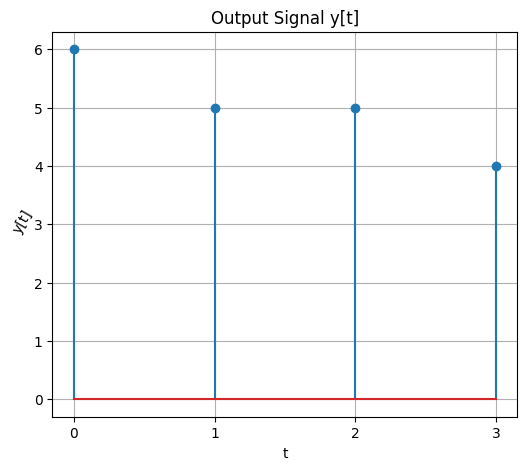

In [11]:
y_np = np.convolve(x, h, mode='same') # call the numpy convolve() function with mode "same" on x and h

# plot the output signal y[t] and the output signal y_np[t]

plot_signal(y_np, 'Output Signal y[t]', 't', 'y[t]', figsize=(6, 5))

## 1st Baptist Church Nashville

An **impulse response** characterizes how a system or environment responds to a single impulse. In acoustics, it captures properties such as reverberation and echoes caused by reflections from walls, ceilings, and other surfaces.

When we convolve an audio signal with an acoustic impulse response, the output sounds as if the signal had been played in the environment described by that impulse response.

In the following, we use a prerecorded impulse response from the [OpenAir Library](https://www.openair.hosted.york.ac.uk/?page_id=406), created by Adam Townsell. This impulse response captures the acoustics of a particular church and allows us to simulate how a sound, such as a voice recording, would behave in that space.

By convolving a speech signal with this impulse response, we can recreate reverberation and other acoustic characteristics of the church environment.

First, we need to download the impulse response and import it into our environment.

In [12]:
fsh, h = wav.read('./audio/1st_baptist_nashville_balcony.wav')
fsx, x = wav.read('./audio/speech.wav')

h = np.mean(h, axis=1)
h = h / np.max(np.abs(h)) 
h = sig.resample(h, int(len(h) * fsx / fsh))

x = x / np.max(np.abs(x))

C:\Users\kerim\AppData\Local\Temp\ipykernel_5412\1811634320.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fsh, h = wav.read('./audio/1st_baptist_nashville_balcony.wav')


(144000,)


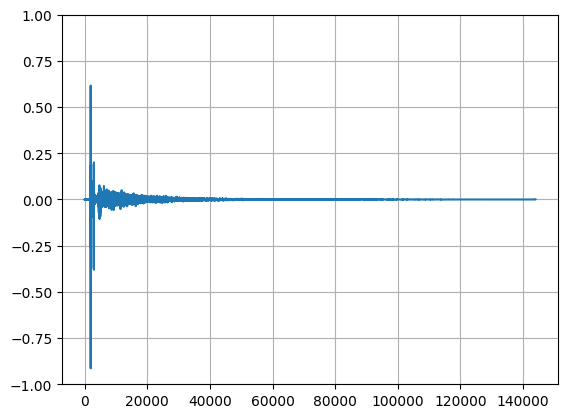

In [13]:
sd.play(data = h, samplerate = fsh, blocking = False)
print(h.shape)
plt.plot(h)
plt.grid()
plt.ylim(-1, 1)
plt.show()

(878592,)


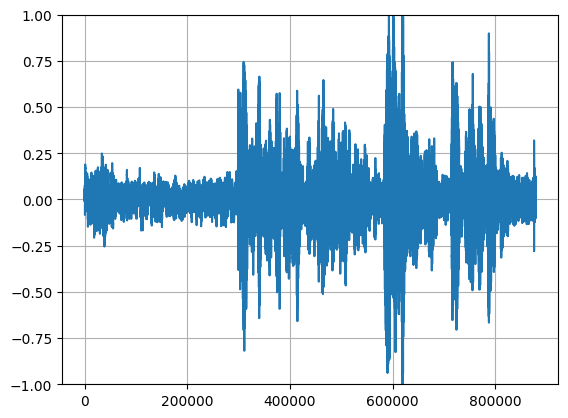

In [14]:
sd.play(data = x, samplerate = fsx, blocking = False)
print(x.shape)
plt.plot(x)
plt.grid()
plt.ylim(-1, 1)
plt.show()

In [15]:
convolved_x = sig.convolve(x, h, mode='same')  # select the appropriate mode
convolved_x /= np.max(np.abs(convolved_x))

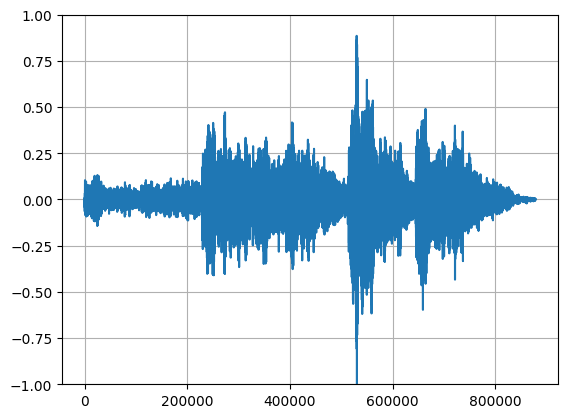

In [16]:
sd.play(data = convolved_x, samplerate = fsx, blocking = False)
plt.plot(convolved_x)
plt.grid()
plt.ylim(-1, 1)
plt.show()

In [17]:
# save to wav
wav.write('./audio/convolved_speech.wav', fsx, convolved_x.astype(np.float32))

## 2d Convolution

### Images are 2d signals

Until now, we have considered only **one-dimensional signals**, whose amplitude values vary over time. However, signals can also be **multidimensional**. A still image, for example, is a **two-dimensional signal**, where the two axes correspond to spatial dimensions, namely height and width. The value at each position, that is, the **pixel value**, represents the intensity or color at a particular spatial location.

In image processing, **kernels** are small matrices, that is, small two-dimensional signals, which are convolved with images to modify or enhance certain properties of the image.

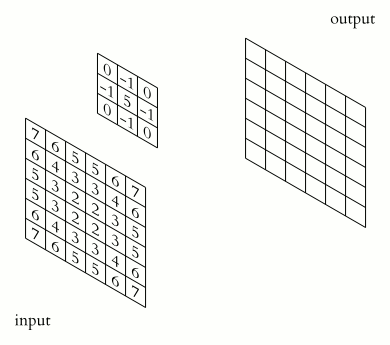

[Source](https://en.wikipedia.org/wiki/Kernel_(image_processing)#Convolution)

$$
g(x, y) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} w(i,j)\,f(x - i, y - j)
$$

Here, $g(x, y)$ denotes the result of convolving the image $f$ with the kernel $w$ at the spatial position $(x,y)$.

In the following we will load an image and 2d-convolve it with various kernels. We will use the `scipy.signal.convolve2d()` function. </br> 
First, we will load a sample image from [scipy.datasets](https://docs.scipy.org/doc/scipy/reference/generated/scipy.datasets.ascent.html#scipy.datasets.ascent).

In [18]:
image = sp.datasets.ascent().astype(np.float32)
print(image.shape)

(512, 512)


The 'image' variable contains the loaded image data in grayscale format.
The shape of the image is (512, 512), which means the image is 512 pixels high (rows) and 512 pixels wide (columns).

Let's define a kernel. Uncomment the kernel you want to use and comment the others:

In [19]:
# Identity kernel
kernel = np.array([[0, 0, 0],
                   [0, 1, 0],
                   [0, 0, 0]])

# # Simple edge detection kernel
# kernel = np.array([[1, 0, -1],
#                    [0, 0, 0],
#                    [-1, 0, 1]])

# # Box blur kernel
# kernel = np.array([[1, 1, 1, 1, 1, 1],
#                     [1, 1, 1, 1, 1, 1],
#                     [1, 1, 1, 1, 1, 1],
#                     [1, 1, 1, 1, 1, 1],
#                     [1, 1, 1, 1, 1, 1],
#                     [1, 1, 1, 1, 1, 1]]) / 36

# Kernel to sharpen the image
# kernel = np.array([[0, -1, 0],
#                    [-1, 5, -1],
#                    [0, -1, 0]])

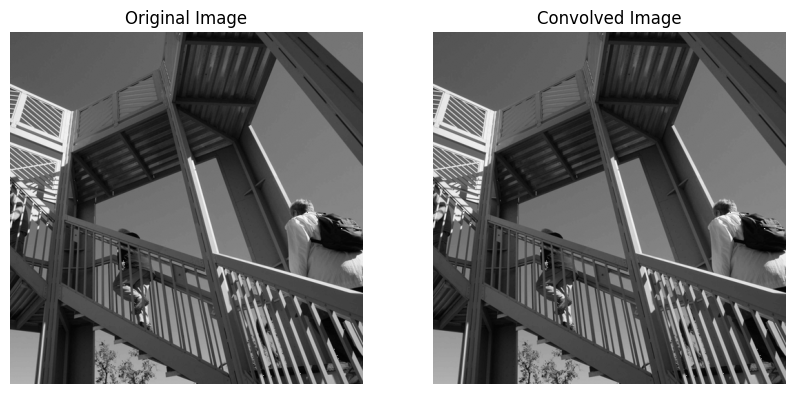

In [20]:
# Apply the kernel to the image using 2D convolution
convolved_image = sp.signal.convolve2d(image, kernel, mode='same') # same mode returns the same size as the input image

# Clip the values to be between 0 and 255
convolved_image = np.clip(convolved_image, 0, 255).astype(np.uint8)

# Plotting the original and convolved image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(convolved_image, cmap='gray')
ax2.set_title('Convolved Image')
ax2.axis('off')

plt.show()

## Conclusions

In this tutorial, we explored the concept of convolution. You are encouraged to look out other use cases to cement your understanding. Below are some additions and bonus tasks for your practice.

---------------------

## Addition

### Circular Convolution

In the following, a circular convolution implementation is provided.

In [21]:
def circ_convolution(x, h):
    # determine the size of convolution output
    N = max(len(x), len(h))

    # ensure that both x and h are of length N by zero-padding if necessary
    if len(x) < N:
        x = np.pad(x, (0, N - len(x)), 'constant')
    if len(h) < N:
        h = np.pad(h, (0, N -  len(h)), 'constant')

    # initialize array of zeros for the output signal
    y = np.zeros(N)

    # Perform circular convolution
    for n in range(N):
        for m in range(N):
            y[n] += x[m] * h[(n - m) % N]

    return y

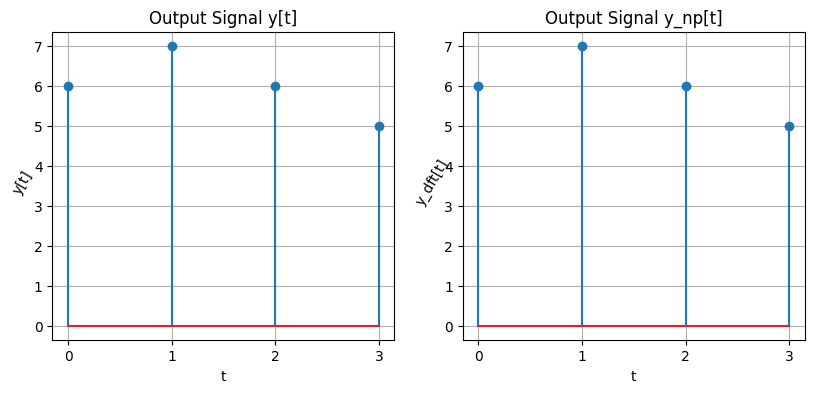

In [22]:
x = [1, 2, 0, 1]
h = [2, 2, 1, 1]

y = circ_convolution(x, h)


# For DFT, multiplication in the frequency domain is equivalent to circular convolution in the time domain
N = max(len(x), len(h))
X = np.fft.fft(x, n=N)
H = np.fft.fft(h, n=N)
Y = X * H
y_dft = np.fft.ifft(Y).real


# plot the output signal y[t] and the output signal y_np[t]

plt.figure(figsize=(15, 4))
plot_signal(y, 'Output Signal y[t]', 't', 'y[t]', subplot=131)
plot_signal(y_dft, 'Output Signal y_np[t]', 't', 'y_dft[t]', subplot=132)
plt.show()